# Logistic Regression with Pytorch

In [1]:
# importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
print("import success")

import success


In [2]:
df = pd.read_csv("student_exam_performance_dataset.csv")
df['pass_fail'] = np.where(df['pass_fail'] == "Fail", 0, 1)  # Target variable must be binary
df.head()

,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,...,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
0,S00001,Male,17,High School,Medium,Yes,Quiet,2.98,96.5,6.05,...,1,Yes,42.8,62.4,54.8,51.8,49.1,2.44,0,F
1,S00002,Female,18,High School,Low,Yes,Quiet,4.45,95.7,6.96,...,0,Yes,77.9,73.5,64.4,61.6,70.1,2.79,1,C
2,S00003,Male,17,High School,Medium,No,Quiet,3.75,76.0,7.02,...,4,Yes,53.5,38.3,36.3,47.1,42.2,1.49,0,F
3,S00004,Male,18,Bachelor,Medium,Yes,Quiet,2.03,72.6,6.23,...,4,No,28.3,23.5,32.0,39.0,31.9,1.34,0,F
4,S00005,Male,18,Bachelor,Medium,Yes,Quiet,5.14,87.3,8.54,...,0,No,74.7,54.9,73.6,55.5,66.4,2.60,1,C


In [3]:
df.describe()

,age,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,16.486900,3.019702,84.703770,7.018894,2.51730,79.491450,69.81681,2.029300,49.503410,49.755600,49.650940,49.759010,49.681910,1.984944,0.485800
std,1.122744,1.179235,9.509211,0.991714,1.44675,13.763237,14.65927,1.437445,13.879156,13.359603,13.436917,13.825207,12.149823,0.544920,0.499823
min,15.000000,0.500000,50.800000,4.000000,0.00000,40.000000,20.00000,0.000000,0.000000,0.000000,0.000000,4.800000,4.400000,0.000000,0.000000
25%,15.000000,2.200000,78.275000,6.337500,1.50000,70.200000,59.80000,1.000000,40.000000,40.800000,40.700000,40.300000,41.600000,1.610000,0.000000
50%,16.000000,3.010000,85.100000,7.030000,2.50000,80.000000,69.90000,2.000000,49.300000,49.600000,49.600000,49.600000,49.550000,1.990000,0.000000
75%,17.000000,3.830000,91.900000,7.690000,3.50000,90.000000,80.10000,3.000000,58.600000,58.500000,58.600000,59.000000,57.600000,2.350000,1.000000
max,18.000000,7.240000,100.000000,10.000000,8.00000,100.000000,100.00000,9.000000,100.000000,100.000000,100.000000,100.000000,97.800000,3.990000,1.000000


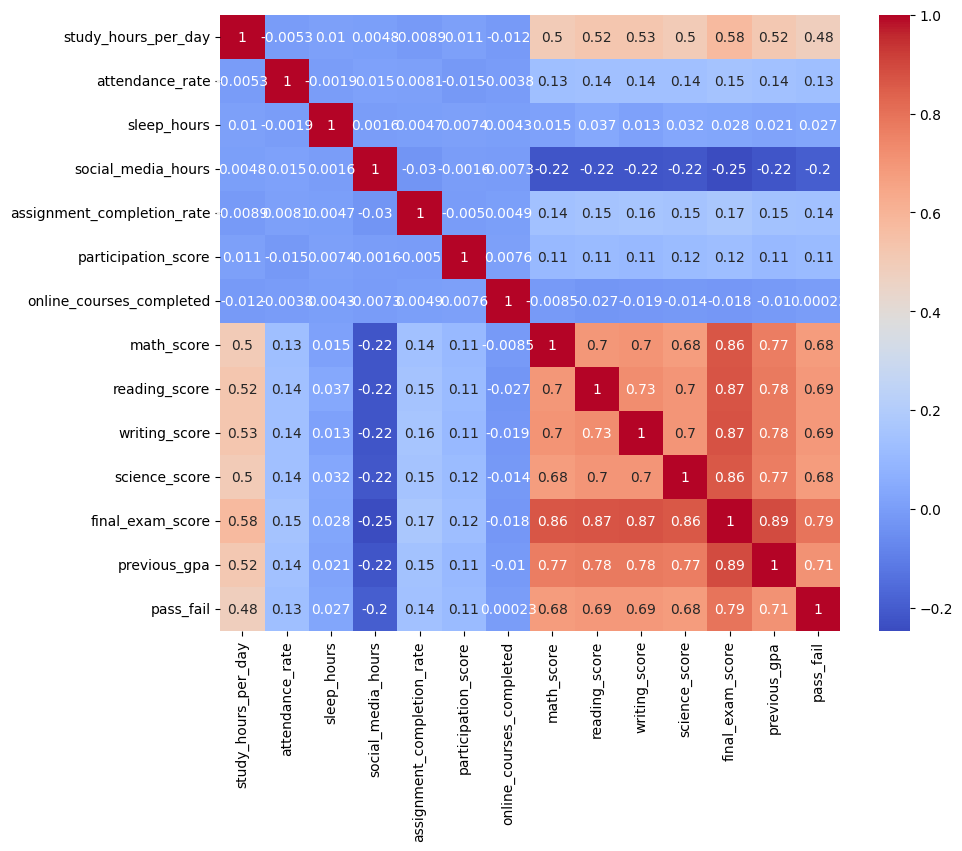

In [16]:
numerical_df = df.drop(labels=["student_id", 
                               "gender", 
                               "age", 
                               "parental_education", 
                               "family_income", 
                               "internet_access", 
                               "study_environment", 
                               "tutoring", 
                               "grade_category"], axis=1)
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap="coolwarm")
plt.show()

## Split and Preprocess Data

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
print("import success")

import success


In [17]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    df[["study_hours_per_day", "social_media_hours", 'previous_gpa']], df["pass_fail"], test_size=0.2, random_state=42
)

print(type(X_train_raw))
print(type(X_test_raw))
print(type(y_train_raw))
print(type(y_test_raw))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


In [18]:
print(f"Length of training data: {len(X_train_raw)}")
print(f"Length of training data targets: {len(y_train_raw)}")
print(f"Length of testing data: {len(X_test_raw)}")
print(f"Length of testing data targets: {len(y_test_raw)}")

Length of training data: 8000
Length of training data targets: 8000
Length of testing data: 2000
Length of testing data targets: 2000


In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train_raw.values, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test_raw.values, dtype=torch.float32).view(-1, 1)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([8000, 3]) torch.Size([8000, 1])
torch.Size([2000, 3]) torch.Size([2000, 1])


## Create Model

In [8]:
class LogisticRegressionModel(nn.Module):
    def __init__(self, num_inputs):
        super().__init__()
        self.linear = nn.Linear(num_inputs, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))  # fit the linear model into a sigmoid to get a probability

In [20]:
model = LogisticRegressionModel(3)
criterion = nn.BCELoss()  # change the loss function to BCE
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [24]:
epochs = 5001

for epoch in range(epochs):
    model.train()
    y_pred_probs = model(X_train)
    loss = criterion(y_pred_probs, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if not epoch % 500:
        print(f'Epoch {epoch}: Loss = {loss.item():.4f}')

Epoch 0: Loss = 0.3070
Epoch 500: Loss = 0.3070
Epoch 1000: Loss = 0.3070
Epoch 1500: Loss = 0.3070
Epoch 2000: Loss = 0.3070
Epoch 2500: Loss = 0.3070
Epoch 3000: Loss = 0.3070
Epoch 3500: Loss = 0.3070
Epoch 4000: Loss = 0.3070
Epoch 4500: Loss = 0.3070
Epoch 5000: Loss = 0.3070


## Model Evaluation

In [11]:
from sklearn.metrics import confusion_matrix
print("import success")

import success


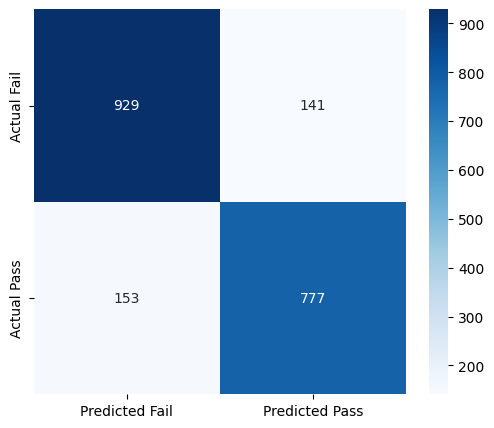

In [25]:
model.eval()

with torch.no_grad():
    test_prob_pred = model(X_test)
    predictions = (test_prob_pred >= 0.5).float()

y_test_np = y_test.detach().cpu().numpy()  # just put detach() and cpu() all the time
prediction_np = predictions.detach().cpu().numpy()

cm = confusion_matrix(y_test_np, prediction_np)  # order is true values, predicted values

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Fail', 'Predicted Pass'],
            yticklabels=['Actual Fail', 'Actual Pass'])  # x axis is predicted, y axis is actual
plt.show()

In [26]:
print(f"Accuracy: {(prediction_np == y_test_np).mean()}")

Accuracy: 0.853
